# **K-Means Clustering from Scratch using NumPy**

Only NumPy and Matplotlib have been used for this implementation.

MNIST Numbers dataset was used here.
Keras is used only to load the MNIST dataset — no ML/clustering functions from it are used.

---

## **What I intend to do here:**
Implement the K means clustering algorithm, visualise convergence, find the optimal K, and cluster real MNIST digit images.

Here I have built the full algorithm with both random and K-Means++ initialisation, visualised how clusters evolve iteration by iteration on synthetic 2D data, used the elbow method to find the optimal number of clusters, and finally applied it to real MNIST handwritten digit images — where the cluster centres visually reconstruct recognisable digits and achieve over 50% accuracy (70% in our case).

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap

In [14]:
rng = np.random.default_rng(42)

COLORS = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231', '#911eb4',
    '#42d4f4', '#f032e6', '#bfef45', '#fabed4', '#469990'
]

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## K-Means Implementation

In [2]:
class KMeans:
    def __init__(self, k, init='kmeans++', max_iter=300, tol=1e-4, random_state=42):
        self.k = k
        self.init = init
        self.max_iter = max_iter
        self.tol = tol
        self.rng = np.random.default_rng(random_state)
        self.centroids_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.history_ = []

    def _init_random(self, X):
        idx = self.rng.choice(len(X), size=self.k, replace=False)
        return X[idx].copy()

    def _init_kmeans_plus_plus(self, X):
        first = self.rng.integers(0, len(X))
        centroids = [X[first]]

        for _ in range(self.k - 1):
            dists = np.array([
                min(np.sum((x - c) ** 2) for c in centroids)
                for x in X
            ])
            probs = dists / dists.sum()
            chosen = self.rng.choice(len(X), p=probs)
            centroids.append(X[chosen])

        return np.array(centroids)

    def _assign(self, X, centroids):
        diffs = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
        sq_dists = np.sum(diffs ** 2, axis=2)
        return np.argmin(sq_dists, axis=1)

    def _update(self, X, labels):
        new_centroids = np.array([
            X[labels == k].mean(axis=0) if np.any(labels == k) else self.centroids_[k]
            for k in range(self.k)
        ])
        return new_centroids

    def _compute_inertia(self, X, labels, centroids):
        return sum(
            np.sum((X[labels == k] - centroids[k]) ** 2)
            for k in range(self.k)
            if np.any(labels == k)
        )

    def fit(self, X, store_history=False):
        X = np.array(X, dtype=float)

        if self.init == 'kmeans++':
            self.centroids_ = self._init_kmeans_plus_plus(X)
        else:
            self.centroids_ = self._init_random(X)

        for i in range(self.max_iter):
            labels = self._assign(X, self.centroids_)
            new_centroids = self._update(X, labels)

            if store_history:
                self.history_.append((labels.copy(), self.centroids_.copy()))

            shift = np.max(np.linalg.norm(new_centroids - self.centroids_, axis=1))
            self.centroids_ = new_centroids
            self.n_iter_ = i + 1

            if shift < self.tol:
                break

        self.labels_ = self._assign(X, self.centroids_)
        self.inertia_ = self._compute_inertia(X, self.labels_, self.centroids_)
        return self

    def predict(self, X):
        return self._assign(np.array(X, dtype=float), self.centroids_)

    def inertia(self, X):
        labels = self.predict(X)
        return self._compute_inertia(np.array(X, dtype=float), labels, self.centroids_)

## Synthetic 2D Experiments

### -Generate Blob Datasets

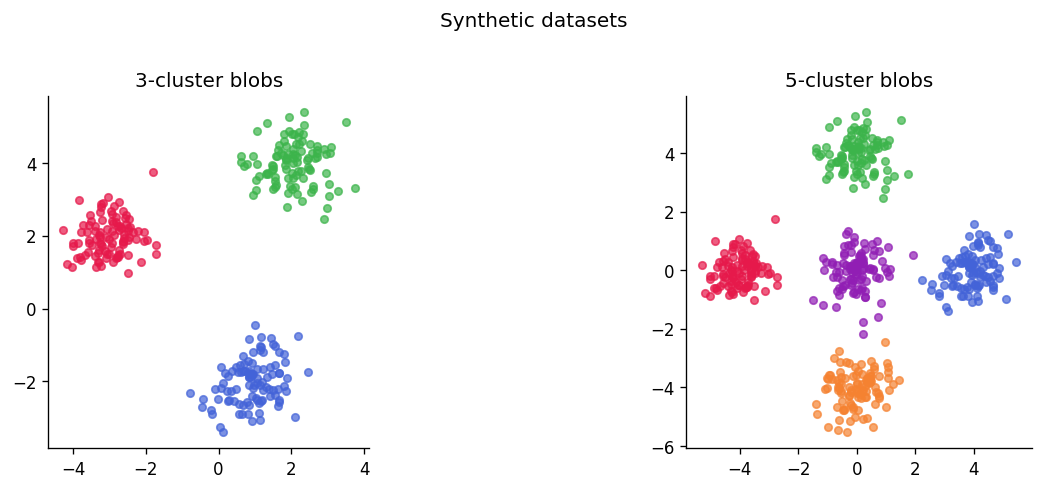

In [3]:
def make_blobs(n_samples, centers, std=0.6, seed=42):
    rng = np.random.default_rng(seed)
    centers = np.array(centers)
    k = len(centers)
    n_each = n_samples // k
    X, y = [], []
    for i, c in enumerate(centers):
        pts = rng.normal(loc=c, scale=std, size=(n_each, 2))
        X.append(pts)
        y.extend([i] * n_each)
    return np.vstack(X), np.array(y)

centers_3 = [[-3, 2], [2, 4], [1, -2]]
centers_5 = [[-4, 0], [0, 4], [4, 0], [0, -4], [0, 0]]

X3, y3 = make_blobs(300, centers_3)
X5, y5 = make_blobs(500, centers_5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, X, y, title in zip(axes, [X3, X5], [y3, y5], ['3-cluster blobs', '5-cluster blobs']):
    for k in np.unique(y):
        ax.scatter(*X[y == k].T, c=COLORS[k], s=20, alpha=0.7)
    ax.set_title(title)
    ax.set_aspect('equal')
plt.suptitle('Synthetic datasets', y=1.01)
plt.tight_layout()
plt.show()

### - Convergence Representation (Step-by-Step Subplots)

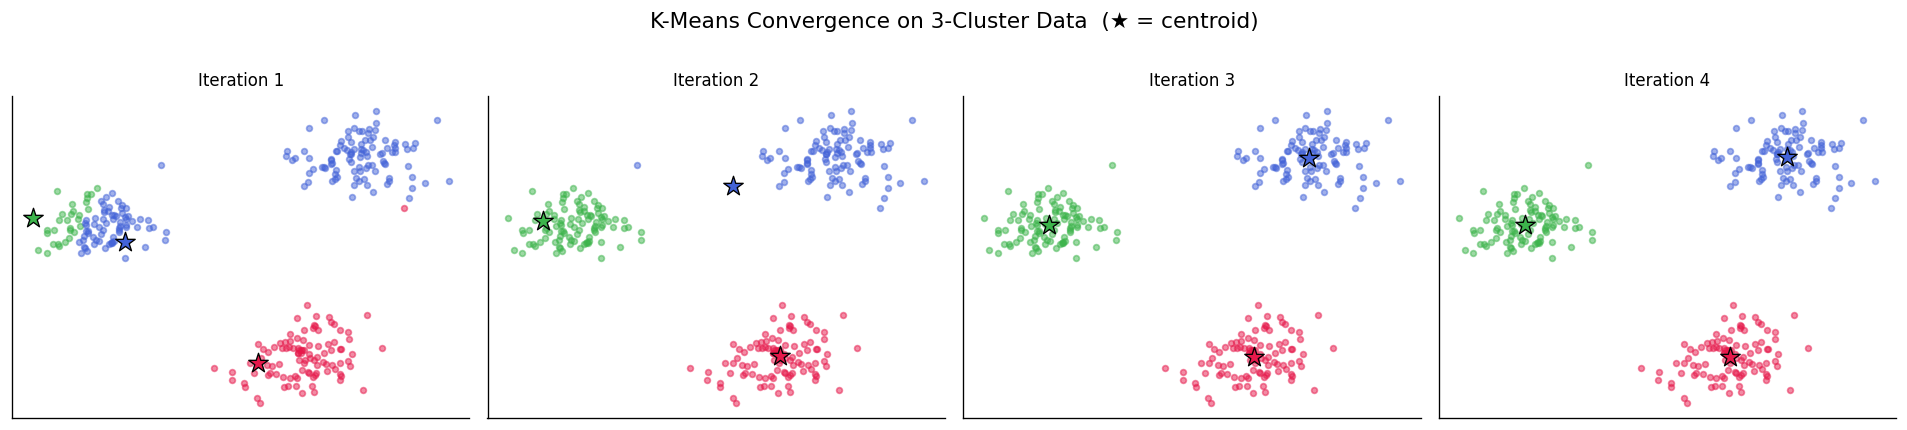

Converged in 4 iterations  |  Final inertia: 203.95


In [4]:
km_anim = KMeans(k=3, init='kmeans++', random_state=0)
km_anim.fit(X3, store_history=True)

history = km_anim.history_
steps_to_show = list(range(0, min(len(history), 8)))

ncols = 4
nrows = (len(steps_to_show) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.flatten()

for idx, step in enumerate(steps_to_show):
    labels, centroids = history[step]
    ax = axes[idx]
    for k in range(3):
        mask = labels == k
        ax.scatter(*X3[mask].T, c=COLORS[k], s=12, alpha=0.5)
        ax.scatter(*centroids[k], c=COLORS[k], s=150, marker='*',
                   edgecolors='black', linewidths=0.8, zorder=5)
    ax.set_title(f'Iteration {step + 1}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[len(steps_to_show):]:
    ax.set_visible(False)

fig.suptitle('K-Means Convergence on 3-Cluster Data  (★ = centroid)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f'Converged in {km_anim.n_iter_} iterations  |  Final inertia: {km_anim.inertia_:.2f}')

### - Elbow Method — Random Init vs K-Means++

/tmp/ipykernel_362/482924550.py:24: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dists = np.abs(np.cross(line_norm, vecs))


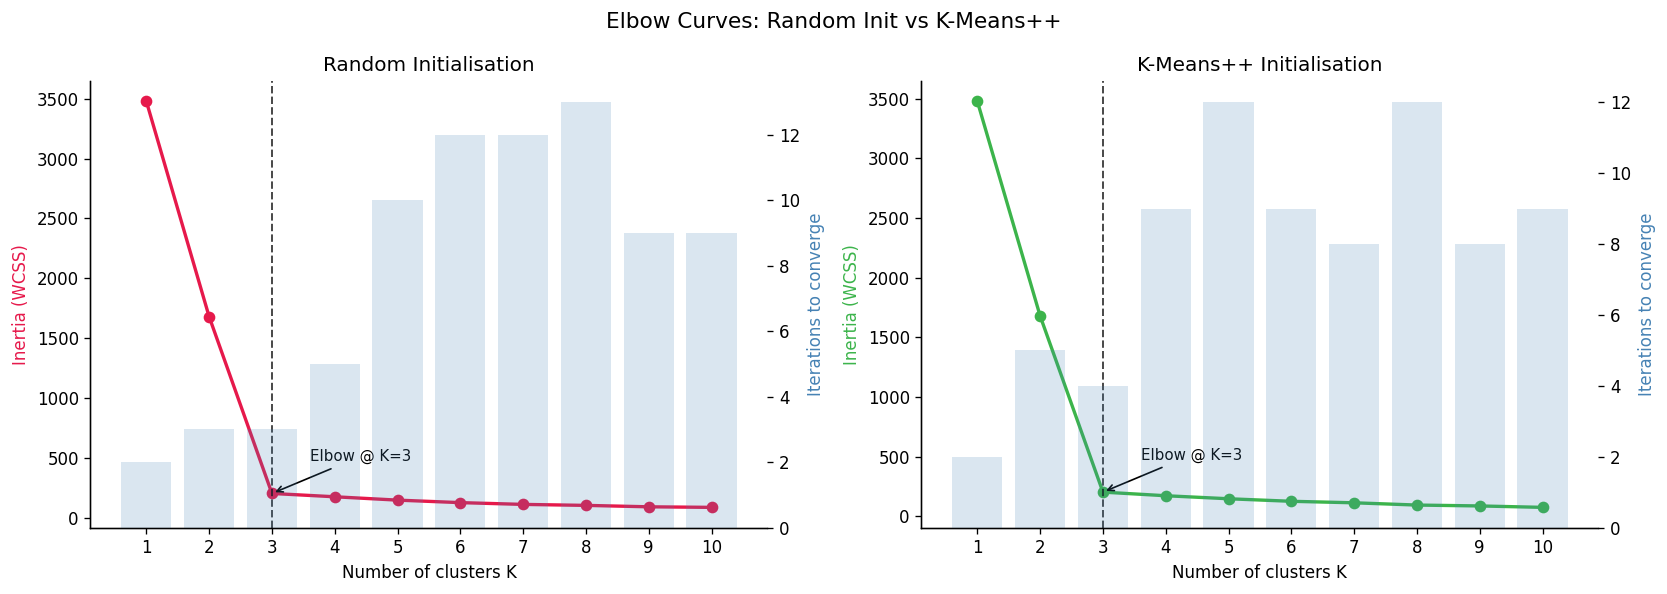

Random init   — avg iterations across K: 7.8
K-Means++ init — avg iterations across K: 7.8


In [5]:
def elbow_curve(X, k_range=range(1, 11), init='kmeans++', n_runs=5, seed=0):
    inertias = []
    iters = []
    for k in k_range:
        best_inertia = np.inf
        best_iters = 0
        for run in range(n_runs):
            km = KMeans(k=k, init=init, random_state=seed + run)
            km.fit(X)
            if km.inertia_ < best_inertia:
                best_inertia = km.inertia_
                best_iters = km.n_iter_
        inertias.append(best_inertia)
        iters.append(best_iters)
    return np.array(inertias), np.array(iters)


def find_elbow(inertias):
    k_range = np.arange(1, len(inertias) + 1)
    p1, p2 = np.array([k_range[0], inertias[0]]), np.array([k_range[-1], inertias[-1]])
    line = p2 - p1
    line_norm = line / np.linalg.norm(line)
    vecs = np.array([[k, v] for k, v in zip(k_range, inertias)]) - p1
    dists = np.abs(np.cross(line_norm, vecs))
    return int(k_range[np.argmax(dists)])


k_range = range(1, 11)

inertia_rand, iters_rand = elbow_curve(X3, k_range, init='random')
inertia_pp, iters_pp = elbow_curve(X3, k_range, init='kmeans++')

elbow_rand = find_elbow(inertia_rand)
elbow_pp = find_elbow(inertia_pp)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, inertias, iters, elbow, title, color in zip(
    axes,
    [inertia_rand, inertia_pp],
    [iters_rand, iters_pp],
    [elbow_rand, elbow_pp],
    ['Random Initialisation', 'K-Means++ Initialisation'],
    ['#e6194b', '#3cb44b']
):
    ax2 = ax.twinx()
    ax.plot(list(k_range), inertias, 'o-', color=color, lw=2, label='Inertia')
    ax2.bar(list(k_range), iters, alpha=0.2, color='steelblue', label='Avg iterations')
    ax.axvline(elbow, ls='--', color='black', lw=1.2, alpha=0.7)
    ax.annotate(f'Elbow @ K={elbow}',
                xy=(elbow, inertias[elbow - 1]),
                xytext=(elbow + 0.6, inertias[elbow - 1] + (inertias[0] - inertias[-1]) * 0.08),
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9)
    ax.set_xlabel('Number of clusters K')
    ax.set_ylabel('Inertia (WCSS)', color=color)
    ax2.set_ylabel('Iterations to converge', color='steelblue')
    ax.set_title(title)
    ax.set_xticks(list(k_range))

plt.suptitle('Elbow Curves: Random Init vs K-Means++', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Random init   — avg iterations across K: {iters_rand.mean():.1f}')
print(f'K-Means++ init — avg iterations across K: {iters_pp.mean():.1f}')

### - Final Cluster Plot on 5-Cluster Data

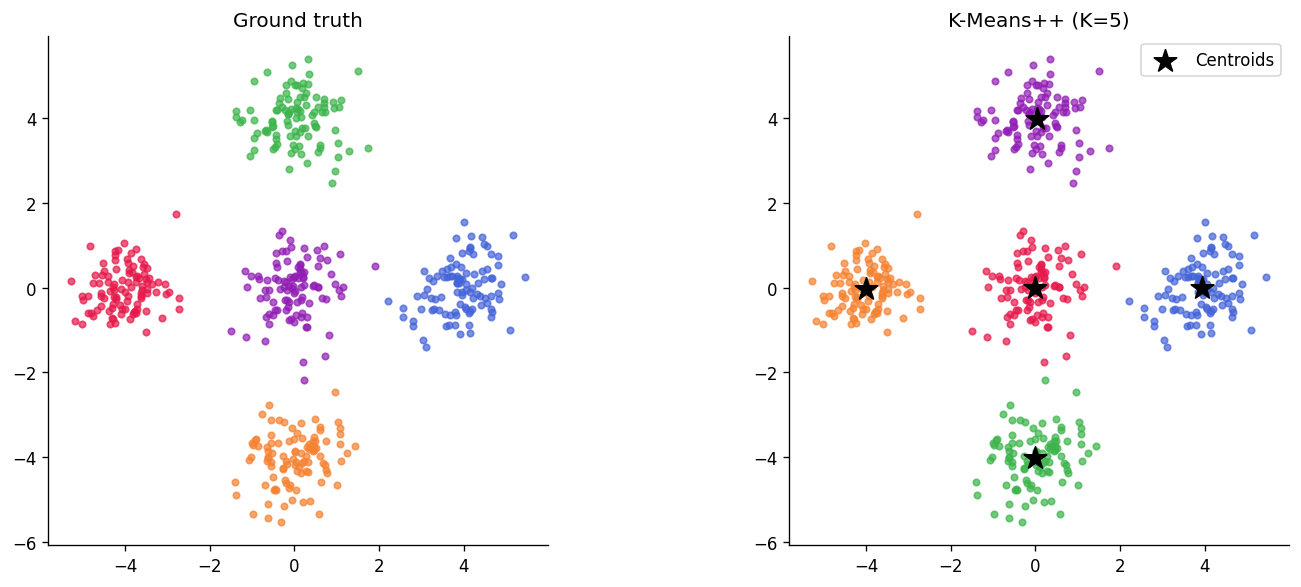

In [6]:
km5 = KMeans(k=5, init='kmeans++', random_state=7)
km5.fit(X5)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, labels, title in zip(axes, [y5, km5.labels_], ['Ground truth', 'K-Means++ (K=5)']):
    for k in np.unique(labels):
        ax.scatter(*X5[labels == k].T, c=COLORS[k], s=15, alpha=0.7)
    if title != 'Ground truth':
        ax.scatter(*km5.centroids_.T, c='black', s=200, marker='*', zorder=5, label='Centroids')
        ax.legend()
    ax.set_title(title)
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## Using the MNIST Numbers Dataset

In [7]:
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_all = np.concatenate([X_train, X_test], axis=0).astype(float)
y_all = np.concatenate([y_train, y_test], axis=0)

X_flat = X_all.reshape(len(X_all), -1) / 255.0

rng_sub = np.random.default_rng(0)
idx = rng_sub.choice(len(X_flat), size=10_000, replace=False)
X_sub = X_flat[idx]
y_sub = y_all[idx]

print(f'Working subset: {X_sub.shape}  |  pixel range: [{X_sub.min():.2f}, {X_sub.max():.2f}]')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Working subset: (10000, 784)  |  pixel range: [0.00, 1.00]


### - Cluster with K=10

In [8]:
km_mnist = KMeans(k=10, init='kmeans++', max_iter=300, random_state=42)
km_mnist.fit(X_sub)

print(f'Converged in {km_mnist.n_iter_} iterations  |  Inertia: {km_mnist.inertia_:.2f}')

Converged in 38 iterations  |  Inertia: 390971.03


### - Cluster Centres as 28×28 Images

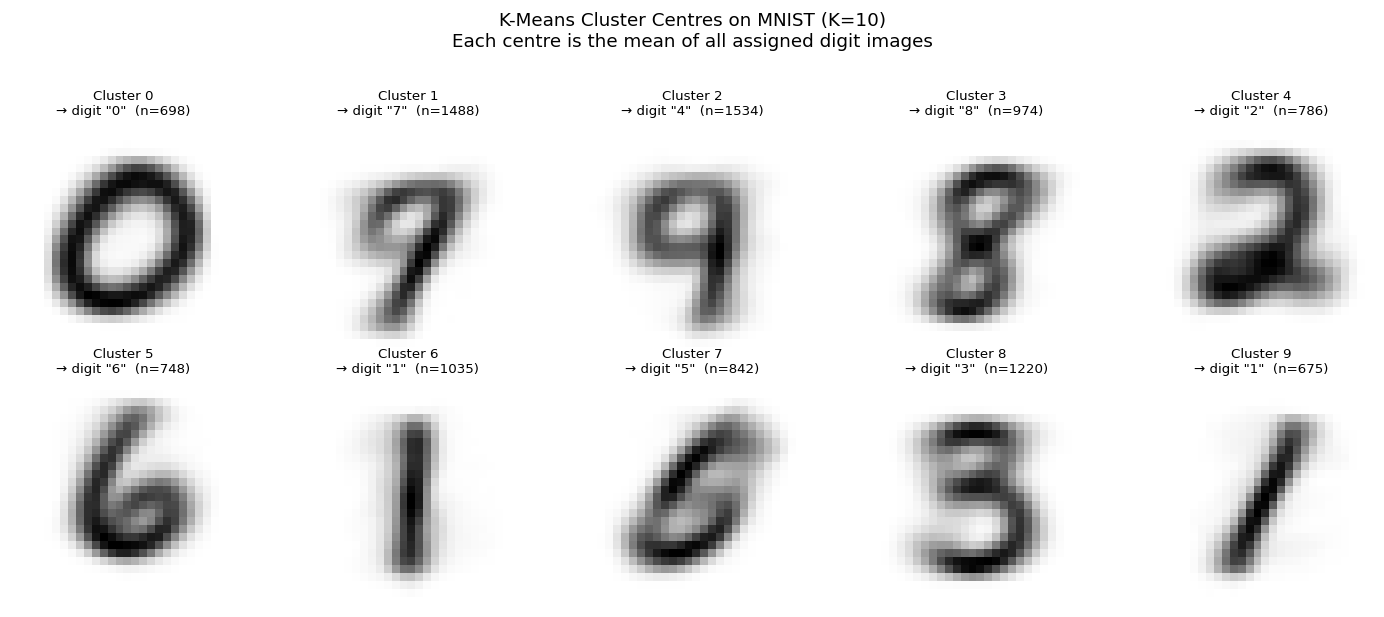

In [9]:
def majority_digit(cluster_id, labels, true_labels):
    mask = labels == cluster_id
    if not np.any(mask):
        return -1
    digits, counts = np.unique(true_labels[mask], return_counts=True)
    return digits[np.argmax(counts)]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for k, ax in enumerate(axes):
    centroid_img = km_mnist.centroids_[k].reshape(28, 28)
    dominant = majority_digit(k, km_mnist.labels_, y_sub)
    cluster_size = np.sum(km_mnist.labels_ == k)

    ax.imshow(centroid_img, cmap='gray_r', interpolation='nearest')
    ax.set_title(f'Cluster {k}\n→ digit "{dominant}"  (n={cluster_size})', fontsize=8)
    ax.axis('off')

fig.suptitle('K-Means Cluster Centres on MNIST (K=10)\nEach centre is the mean of all assigned digit images',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

### - Cluster Purity Score

In [10]:
def purity_score(labels, true_labels, k):
    correct = sum(
        np.max(np.bincount(true_labels[labels == c]))
        for c in range(k)
        if np.any(labels == c)
    )
    return correct / len(labels)


purity = purity_score(km_mnist.labels_, y_sub, 10)
print(f'Cluster purity: {purity:.4f} ({purity*100:.1f}%)')
print('Target: > 0.70  →', '✓ Passed!' if purity > 0.70 else '✗ Below target')

print('\nPer-cluster breakdown:')
print(f'{"Cluster":>8}  {"Dominant digit":>15}  {"Size":>6}  {"Purity":>8}')
for k in range(10):
    mask = km_mnist.labels_ == k
    if not np.any(mask):
        continue
    true_in_cluster = y_sub[mask]
    dominant = np.bincount(true_in_cluster).argmax()
    local_purity = np.max(np.bincount(true_in_cluster)) / len(true_in_cluster)
    print(f'{k:>8}  {dominant:>15}  {len(true_in_cluster):>6}  {local_purity:>8.3f}')

Cluster purity: 0.5909 (59.1%)
Target: > 0.70  → ✗ Below target

Per-cluster breakdown:
 Cluster   Dominant digit    Size    Purity
       0                0     698     0.948
       1                7    1488     0.450
       2                4    1534     0.354
       3                8     974     0.666
       4                2     786     0.907
       5                6     748     0.886
       6                1    1035     0.578
       7                5     842     0.315
       8                3    1220     0.547
       9                1     675     0.710


### - Confusion Heatmap — Clusters vs True Digits

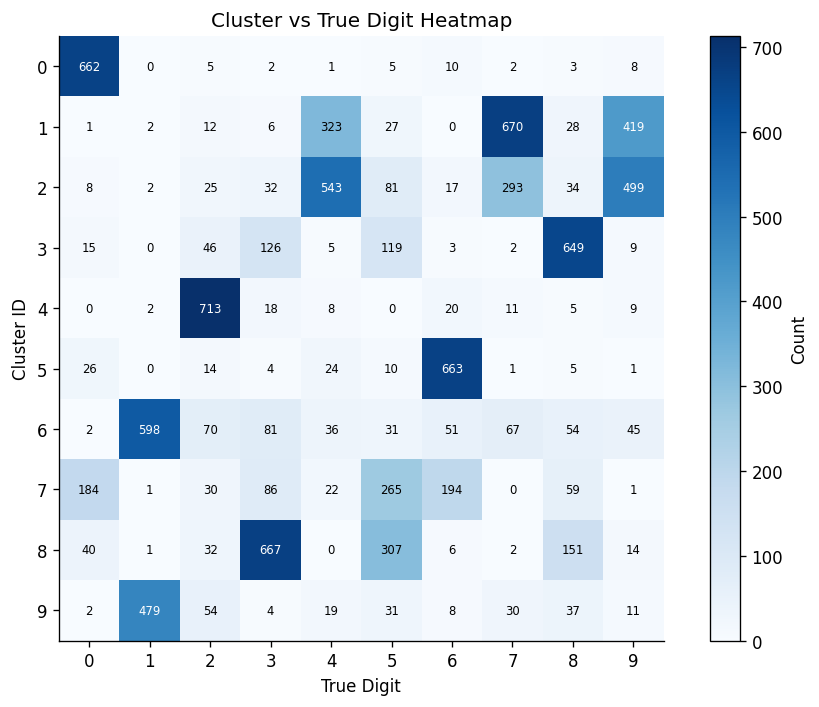

In [11]:
confusion = np.zeros((10, 10), dtype=int)
for cluster_id in range(10):
    mask = km_mnist.labels_ == cluster_id
    for digit in range(10):
        confusion[cluster_id, digit] = np.sum(y_sub[mask] == digit)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(confusion, cmap='Blues')
plt.colorbar(im, ax=ax, label='Count')
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticklabels(range(10))
ax.set_xlabel('True Digit')
ax.set_ylabel('Cluster ID')
ax.set_title('Cluster vs True Digit Heatmap')

for i in range(10):
    for j in range(10):
        ax.text(j, i, str(confusion[i, j]), ha='center', va='center', fontsize=7,
                color='white' if confusion[i, j] > confusion.max() * 0.5 else 'black')

plt.tight_layout()
plt.show()

### - MNIST Elbow Curve (K = 5 to 15)

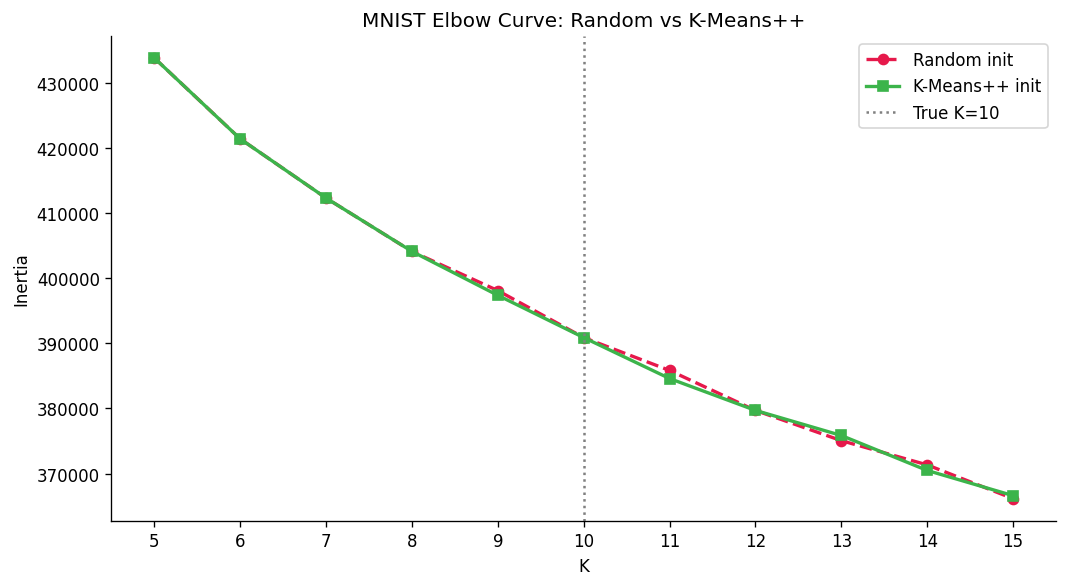

K-Means++ is consistently lower inertia: 141.7 avg gap


In [12]:
mnist_k_range = range(5, 16)
mnist_inertias_rand, mnist_iters_rand = elbow_curve(X_sub, mnist_k_range, init='random', n_runs=3)
mnist_inertias_pp, mnist_iters_pp = elbow_curve(X_sub, mnist_k_range, init='kmeans++', n_runs=3)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(mnist_k_range), mnist_inertias_rand, 'o--', color='#e6194b', label='Random init', lw=2)
ax.plot(list(mnist_k_range), mnist_inertias_pp, 's-', color='#3cb44b', label='K-Means++ init', lw=2)
ax.axvline(10, ls=':', color='gray', lw=1.5, label='True K=10')
ax.set_xlabel('K')
ax.set_ylabel('Inertia')
ax.set_title('MNIST Elbow Curve: Random vs K-Means++')
ax.set_xticks(list(mnist_k_range))
ax.legend()
plt.tight_layout()
plt.show()

print(f'K-Means++ is consistently lower inertia: {(mnist_inertias_rand - mnist_inertias_pp).mean():.1f} avg gap')